# Отток клиентов телекоммуникационной компании

Оператор связи разрабатывает стратегию взаимодействия с клиентами на основе данных. С помощью исследования и кластеризации клиентов необходимо сделать выводы и сформулировать рекомендации для стратегии взаимодействия с клиентами и их удержания.

Данные об оттоке клиентов Telco содержат информацию о вымышленной телекоммуникационной компании, которая предоставляла услуги домашнего телефона и Интернета 7043 клиентам в Калифорнии в третьем квартале. 

#### Задача исследования

На основе анализа данных подготовить план действий по удержанию клиентов.

Перед решением задачи понадобится обзор данных. Затем на этапе предобработка данных исправим ошибки.

На этапе исследования данных посмотрим на среднии значения признаков и колонки оттока. Затем выполним кластеризацию пользователей.

В выводе дадим базовые рекомендации по взаимодействия с клиентами и их удержанием.

**Этапы исследования**
1. Обзор данных.
2. Предобработка данных.
3. Исследовательский аналих данных.
4. Кластеризация пользователей.
5. Вывод


https://www.kaggle.com/datasets/blastchar/telco-customer-churn


In [323]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

# Обзор данных

Составим первое впечетление о входных данных

In [214]:
# сохраним данные в переменную 
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [215]:
# обзор первых 5 строк
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


Каждая строка описывает характеристики пользователя.

Данные по колонкам:
* `customerID` - уникальный id каждого пользователя
* `gender` - пол пользователя
* `SeniorCitizen` - возрас клиента больше 65 лет 
* `Partner` - семейное положение
* `Dependents` - пользователь проживает с родственниками
* `tenure` - общее количество месяцев пользования услугами компании
* `PhoneService` - используется домашняя телефонная связь от компании
* `MultipleLines` - используется несколько телефонных линий от компании
* `InternetService` - подключен интернет от компании
* `OnlineSecurity` - подключены дополнительные услуги безопастности
* `OnlineBackup` - подключены дополнительные услуги резервного копирования
* `DeviceProtection` - подключены дополнительные услуги защиты интернет оборудования
* `TechSupport` - подключен дополнительный план тех обуслуживания с меньшим временем ожидания
* `StreamingTV` - пользователь использует стриминг ТВ от стороннего провайдера
* `StreamingMovies` - пользователь использует стриминг фильмов от стороннего провайдера
* `Contract` - тип контракта
* `PaperlessBilling` - онлайн способ оплаты
* `PaymentMethod` - каким способом клиент оплачивает счета
* `MonthlyCharges` - месячная плата за все услуги
* `TotalCharges` - общие расходы рассчитанные до конца квартала
* `Churn` - показатель оттока пользователя

Название столбцов написаны в неудобном стиле. Нужно будет их заменить.

In [216]:
# посмотрим на общую информацию по таблице
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Таблица содержит 7043 строк и 21 колонок. Пропусков не обнаружено. 

Некоторые колонки имеют тип `object`. Для анализа данных нудно булет их перевести в тип `int8`.

Колонка `TotalCharges` имеет несоответствие типов данных. Нужно будет заменить `object` на `float64`.

In [217]:
# посмотрим на значение в тех
# колонках, где количество уникальных
# значений меньше 10 и тип колонки 'object'
for i in df.columns:
    if (df[i].dtype == 'object' and
           df[i].nunique() < 10):
        print(i, df[i].unique())

gender ['Female' 'Male']
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
PhoneService ['No' 'Yes']
MultipleLines ['No phone service' 'No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes' 'No internet service']
OnlineBackup ['Yes' 'No' 'No internet service']
DeviceProtection ['No' 'Yes' 'No internet service']
TechSupport ['No' 'Yes' 'No internet service']
StreamingTV ['No' 'Yes' 'No internet service']
StreamingMovies ['No' 'Yes' 'No internet service']
Contract ['Month-to-month' 'One year' 'Two year']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn ['No' 'Yes']


Для удобства анализа параметров выборки, заменим значения колонок `gender`, `partner`, `dependents`, `phone_service`, `paperless_billing`, `churn` на значения 0/1. 

#### Вывод

В таблице данные о пользователях вымешленной телекоммуникационной компании Telco за 3 кварта 2019 года.

1. Для анализа доступно 7043 строк.
2. Пропусков не обнаружено.
3. Назвния столбцов написаны в неудобном стиле.
4. Колонка `TotalCharges` имеет несоответствие типов данных.
5. 16 колонок из 17 с типом `object` имеют меньше 4 уникальных значений.

# Предобработка данных

### Стиль заголовков

In [218]:
# заменим стиль колонок CamelCase на snake_case
columns = {
    'customerID': 'customer_id',
    'SeniorCitizen': 'senior_citizen',
    'PhoneService': 'phone_service',
    'MultipleLines': 'multiple_lines',
    'InternetService': 'internet_service',
    'OnlineSecurity': 'online_security',
    'OnlineBackup': 'online_backup',
    'DeviceProtection': 'device_protection',
    'TechSupport': 'tech_support',
    'StreamingTV': 'streaming_tv',
    'StreamingMovies': 'streaming_movies',
    'PaperlessBilling': 'paperless_billing',
    'PaymentMethod': 'payment_method',
    'MonthlyCharges': 'monthly_charges',
    'TotalCharges': 'total_charges',
}

df = df.rename(columns=columns)

# проверка
df.columns

Index(['customer_id', 'gender', 'senior_citizen', 'Partner', 'Dependents',
       'tenure', 'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'Contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'Churn'],
      dtype='object')

In [219]:
# заменяем верхний регистр на нижний
df.columns = df.columns.str.lower()

df.columns

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure', 'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn'],
      dtype='object')

## Изменение типов данных

In [220]:
# в колонке `total_charges` присутствует пропуск типа ` `
# заменим его на большое отрицательное число 
df['total_charges'] = df['total_charges'].replace(' ', -9999)

# поменяем тип колонки на float64
df['total_charges'] = df['total_charges'].astype('float64')

# и посмотрим на количество таких значений
df[df['total_charges'] == -9999].shape

(11, 21)

В колонке `total_charges` всего 11 пропусков. 

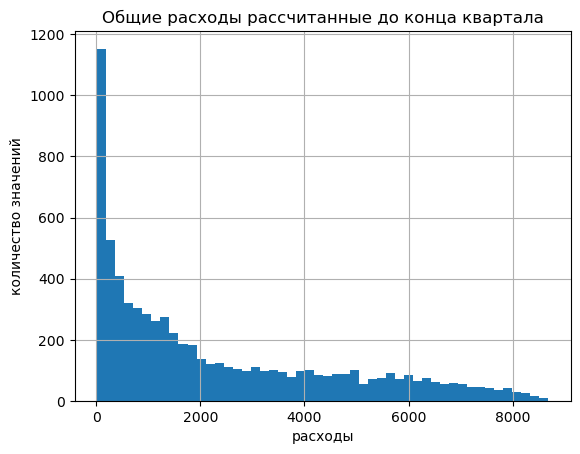

In [221]:
# посмотрим гистограмму колонки total_charges
# без значения -9999
df[df['total_charges'] != -9999]['total_charges'].hist(bins=50)

plt.title('Общие расходы рассчитанные до конца квартала')
plt.xlabel('расходы')
plt.ylabel('количество значений')

plt.show()

In [222]:
# среднее значение будет смещенно за счет длинного хвоста
# заменим значение -9999 на медиану
total_charges_median = df[df['total_charges'] != -9999]['total_charges'].median()
df['total_charges'] = df['total_charges'].replace({-9999: total_charges_median})

## Замена значений в колонках

In [239]:
# создадим список с названиями колонок
# для изменения значений
values = {
    'gender': {'Male': 0, 'Female': 1},
    'partner': {'No': 0, 'Yes': 1},
    'dependents': {'No': 0, 'Yes': 1},
    'phone_service': {'No': 0, 'Yes': 1},
    'paperless_billing': {'No': 0, 'Yes': 1},
    'churn': {'No': 0, 'Yes': 1}
}

# и заменим старые значения в датафрейме
df = df.replace(values)

In [241]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
gender,7043.0,0.495244,0.500013,0.00,0.000,0.000,1.00,1.00
senior_citizen,7043.0,0.162147,0.368612,0.00,0.000,0.000,0.00,1.00
partner,7043.0,0.483033,0.499748,0.00,0.000,0.000,1.00,1.00
dependents,7043.0,0.299588,0.458110,0.00,0.000,0.000,1.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.000,29.000,55.00,72.00
phone_service,7043.0,0.903166,0.295752,0.00,1.000,1.000,1.00,1.00
paperless_billing,7043.0,0.592219,0.491457,0.00,0.000,1.000,1.00,1.00
monthly_charges,7043.0,64.761692,30.090047,18.25,35.500,70.350,89.85,118.75
total_charges,7043.0,2281.916928,2265.270398,18.80,402.225,1397.475,3786.60,8684.80
churn,7043.0,0.265370,0.441561,0.00,0.000,0.000,1.00,1.00


## Обработка дубликатов

In [242]:
# посмотрим количество дубликатов
df.duplicated().sum()

0

Дубликаты строк отсутствуют.

#### Вывод

На этапе предобработки данных мы исправили стиль названия колонок, заменили пропуски, заменили значения бинарных колонок на новые и убедились что дубликаты отсутствуют.

# Исследовательский аналих данных

Посмотрим на средние значения признаков в двух группах (тех, кто ушел в отток и тех, кто остался). Построим столбчатые гистограммы и распределения признаков в двух группах.

## Изучение признаков и их параметров

In [243]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
gender,7043.0,0.495244,0.500013,0.00,0.000,0.000,1.00,1.00
senior_citizen,7043.0,0.162147,0.368612,0.00,0.000,0.000,0.00,1.00
partner,7043.0,0.483033,0.499748,0.00,0.000,0.000,1.00,1.00
dependents,7043.0,0.299588,0.458110,0.00,0.000,0.000,1.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.000,29.000,55.00,72.00
phone_service,7043.0,0.903166,0.295752,0.00,1.000,1.000,1.00,1.00
paperless_billing,7043.0,0.592219,0.491457,0.00,0.000,1.000,1.00,1.00
monthly_charges,7043.0,64.761692,30.090047,18.25,35.500,70.350,89.85,118.75
total_charges,7043.0,2281.916928,2265.270398,18.80,402.225,1397.475,3786.60,8684.80
churn,7043.0,0.265370,0.441561,0.00,0.000,0.000,1.00,1.00


На основе описательной статистики можно сделать предварительные выводе о пользователях телекоммуникационной компании:
* 50% пользователей мужчины, 50% женщины
* 16% пользователей старше 65 лет
* 48% женаты/замужем
* 30% проживают с родственниками
* средняя продолжительность пользования сервисом 32 месяца
* 90% пользователей используют телефонную связь от компании
* 59% предпочитают оплату услуг онлайн
* в среднем пользователю обходятся услуги компании в 65 уе
* общие расходы пользователя 2282 уе
* 27% пользователей ушли в отток

## Сравнение средних значений по факту оттока

In [244]:
(
    df.groupby('churn')
        .mean()
        .T
        .style
        .highlight_min(color='lightyellow', axis=1)
)

churn,0,1
gender,0.492656,0.502408
senior_citizen,0.128721,0.254682
partner,0.528218,0.357945
dependents,0.344801,0.174425
tenure,37.569965,17.979133
phone_service,0.901044,0.909042
paperless_billing,0.535562,0.749064
monthly_charges,61.265124,74.441332
total_charges,2552.882494,1531.796094


Сравним средние значения **попавших в группу оттока** против не попавших:
* **25%** против 13% имеют возрас больше 65 лет
* **36%** против 53% не женаты/замужем
* **17%** против 34% проживают с родствениками
* **18** против 38 месяцев пользуются услгами компании
* **75%** против 54% предпочитаю платить за услуги в онлайне
* **74** против 61 уе в среднем платят пользуватели в месяц
* **1532** против 2553 уе общие расходы до конца 3-го квартала

## Диаграммы признаков по факту оттока

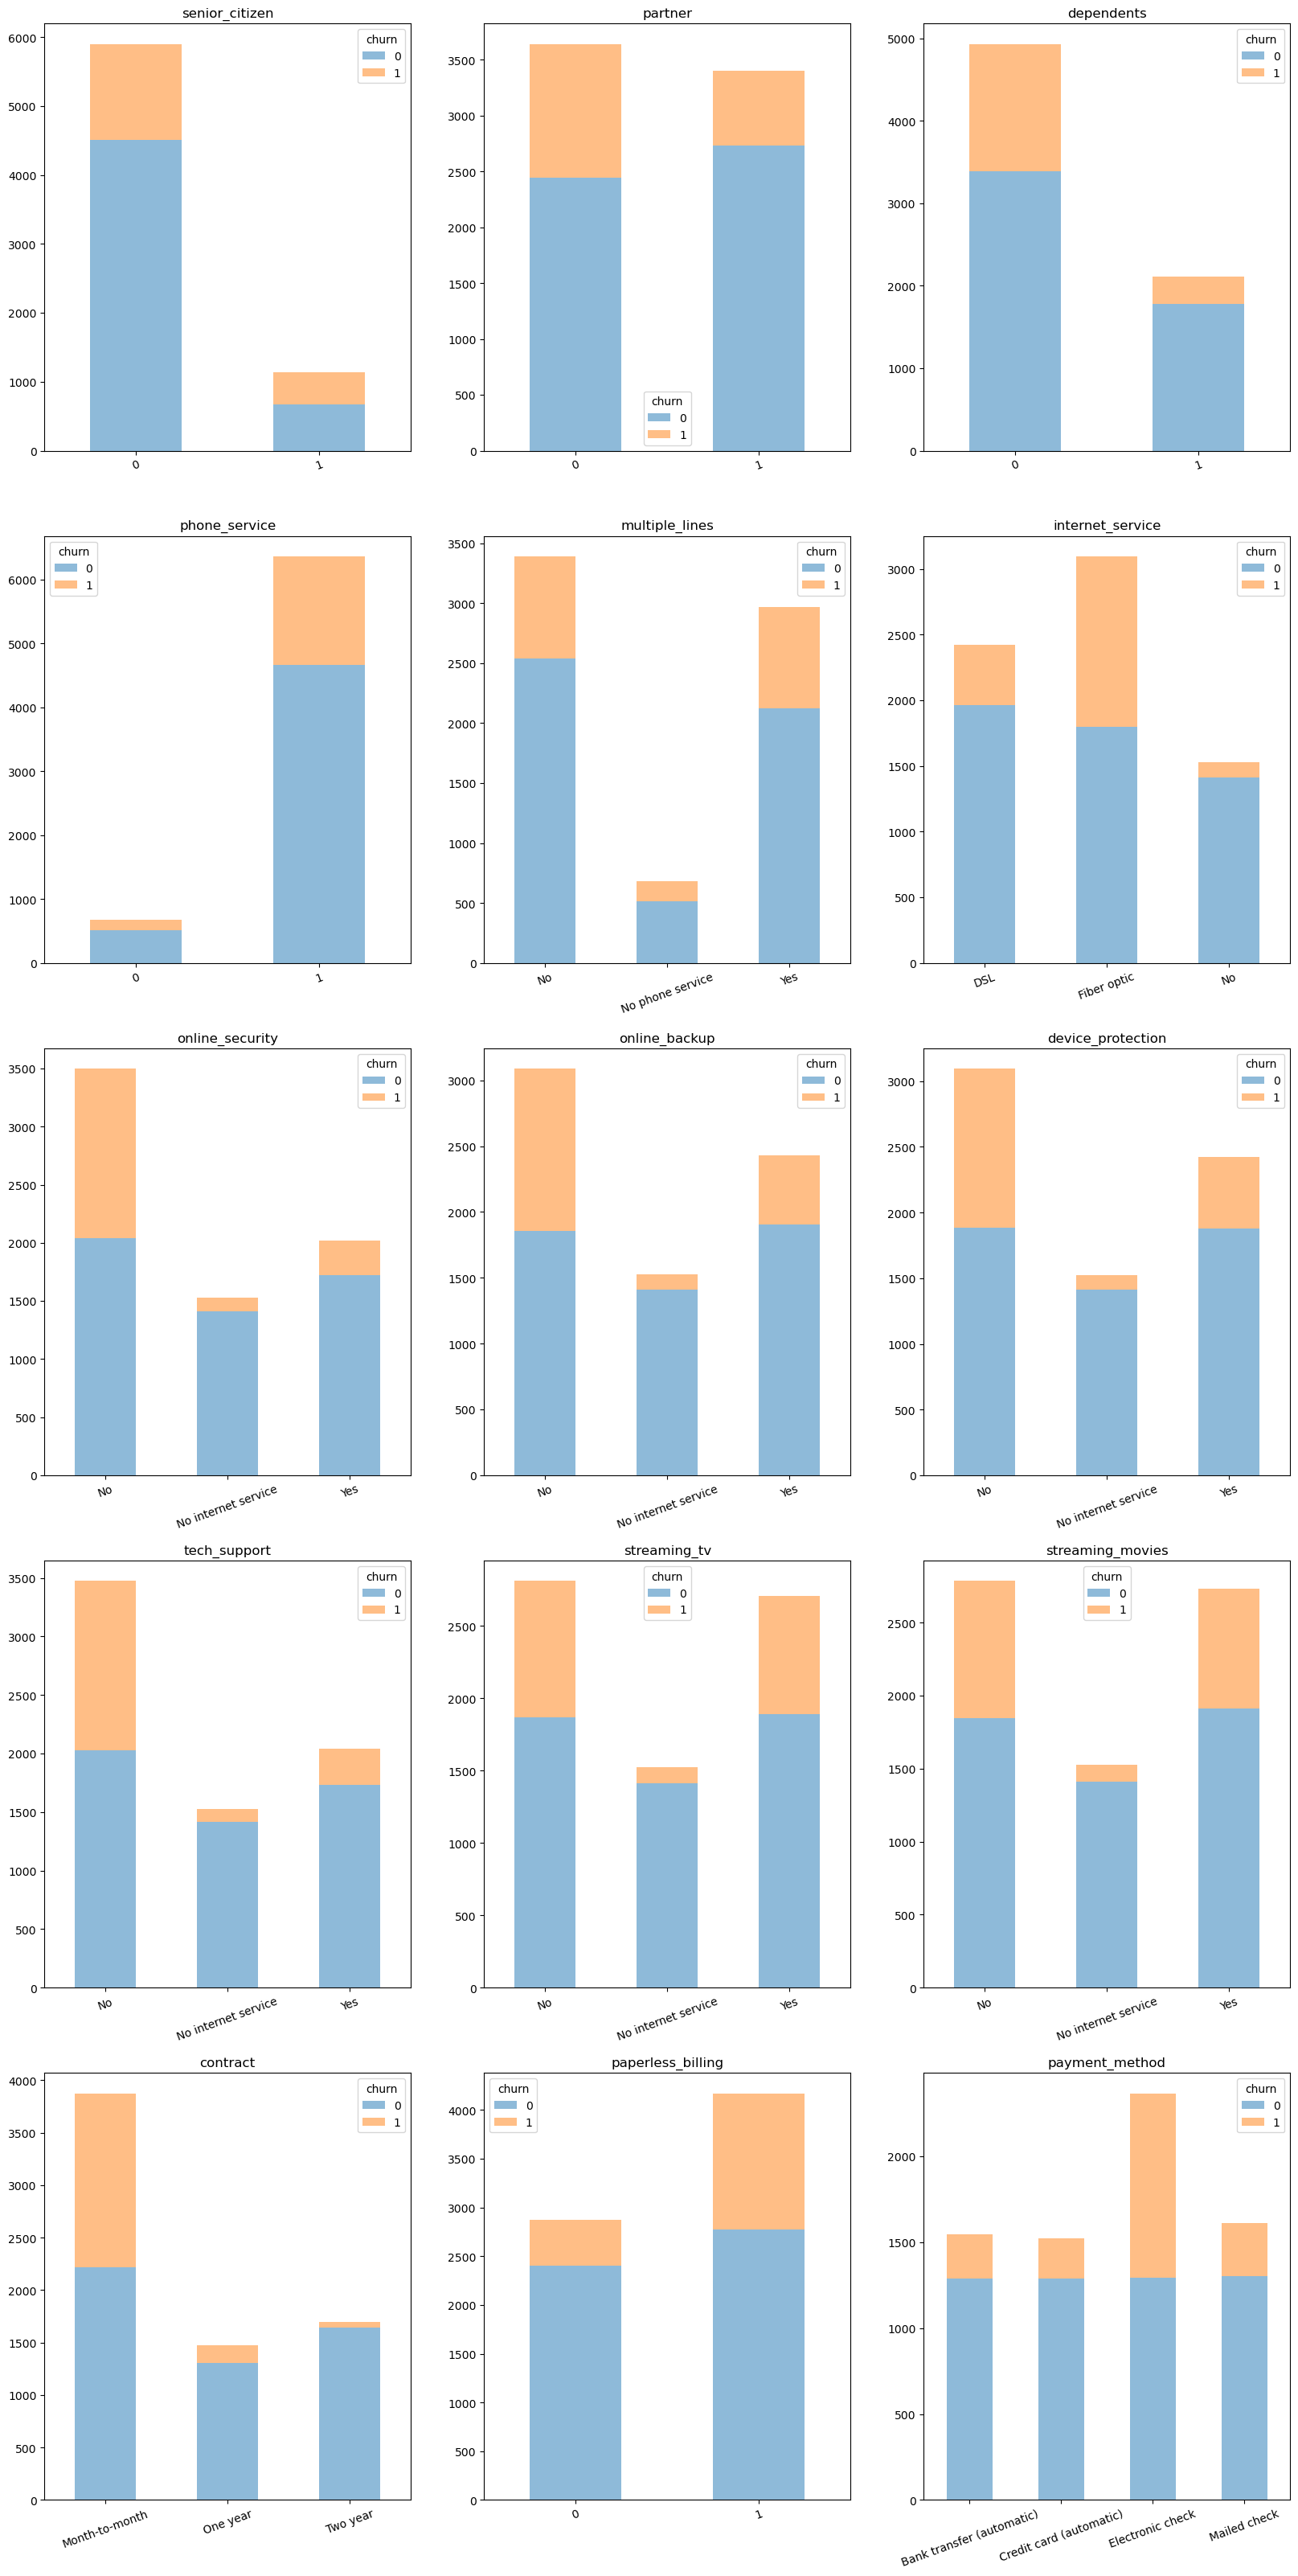

In [245]:
# список колонок для построение диаграмм
columns = [i for i in df.columns if df[i].nunique() <= 4 and i not in ['gender', 'churn']]

# создаем список графиков
fig, axs = plt.subplots(5, 3, figsize=(20, 40))

# изменяем размерность списка axs с 5х3 на 15х1
axs = axs.ravel()

# в цыкле создаем сводную таблицу
# и рисуем график этой таблицы
for i, col in enumerate(columns):
    report = df.pivot_table(index=col, columns='churn', values='gender', aggfunc='count')
    report.plot(ax=axs[i], kind='bar', stacked=True, alpha=0.5)
    axs[i].set_title(col)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('')
    axs[i].tick_params(axis='x', labelrotation=20)
    
plt.show()

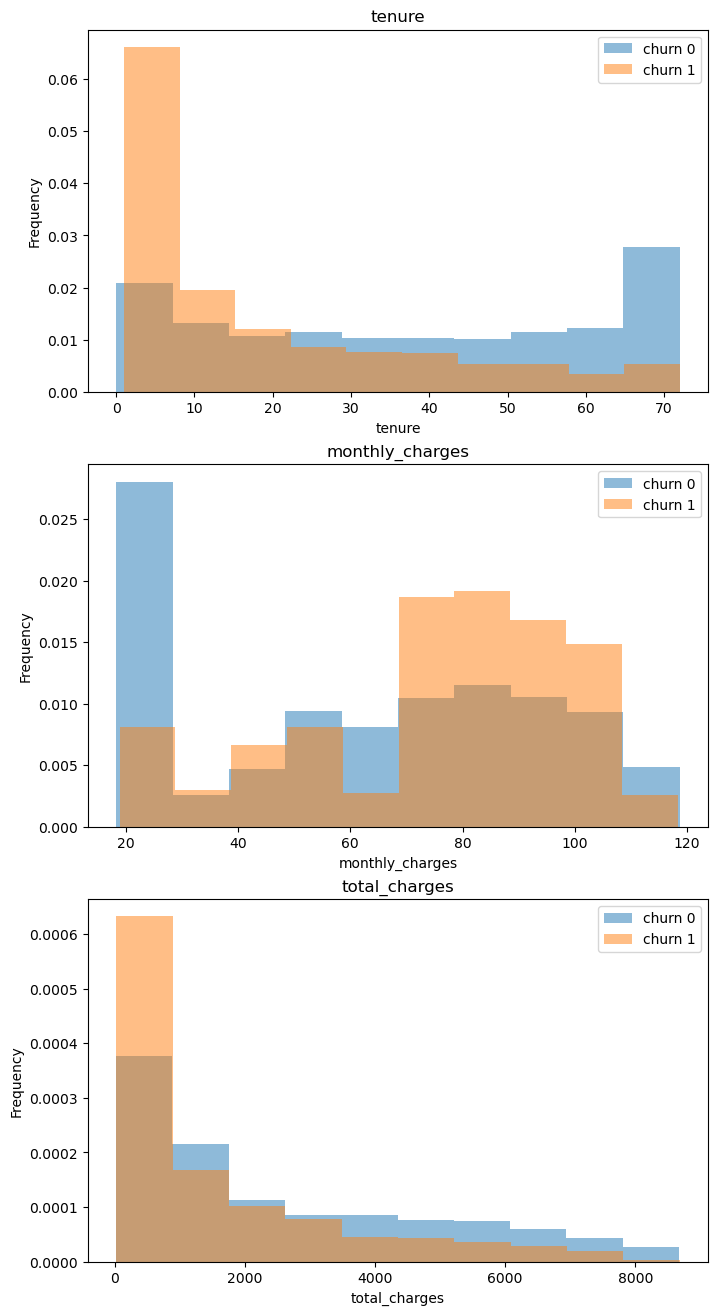

In [246]:
columns = ['tenure', 'monthly_charges', 'total_charges']

fig, axs = plt.subplots(3, 1, figsize=(8, 16))
axs = axs.ravel()

for i, col in enumerate(columns):
    (
        df[df['churn'] == 0][col]
            .plot(
                ax=axs[i],
                kind='hist',
                density=True,
                alpha=0.5,
                label='churn 0',
                legend=True
            )
    )
    (
        df[df['churn'] == 1][col]
            .plot(
                ax=axs[i],
                kind='hist',
                density=True,
                alpha=0.5,
                label='churn 1',
                legend=True
            )
    )
    axs[i].set_title(col)
    axs[i].set_xlabel(col)
plt.show()

На визуализациях отчетливо видно, что в группе оттока больше пользователей которые:
- живут без родственников
- используют оптическое волокно (Fiber optic) в качестве интернет соединения
- не используют дополнительные услуги компании (услуги безопастности, резервного копирования, защиты интернет оборудования, тех. обуслуживания с меньшим временем ожидания)
- имеют контракт без даты окончания (month-to-month)
- предпочитают оплачивать онлайн

Так же следует отметить, что наибольший отток наблюдается для пользователей которые:
- пользуються услугами компании меньше 10 месяцев
- оплачивают в месяц от 70 до 110 уе
- имеют общие расходы до 1500 уе

#### Вывод

Изучив средние значение, мы составили общее представление о пользователях:
- половина пользователей мужчины, половина женщины
- каждый шестой старше 65 лет
- 90% используют телефонную связь от компании, 59% оплачивают услуги онлайн
- средняя продолжительность пользования сервисом 32 месяца
- 65 уе в среднем платят пользователи за услуги
- 27% пользователей ушли в отток


Сравнив пользователей попавших в отток, с теми кто не попал в группу оттока, мы увидели основные отличия:
- чаще заключают контракт без даты окончания и оплачивают услуги онлайн
- меньше пользуются дополнительными услугами
- большинство тех, кто попал в группу оттока, пользуються услугами компании меньше 10 месяцев

# Предобработка данных для кластеризации

Проведем исправлнение категориальных данных

In [302]:
def change_categorical_columns(dataframe, columns):
    """ Составляет словарь с новыми 
    категориальными значениями
    """
    values = {}
    for i in columns:
        unique_values = dataframe[i].unique()
        values[i] = {i:index for index, i in enumerate(unique_values)}
    return values

# список колонок для исправления
columns = [i for i in df.columns if df[i].dtype == 'object' and df[i].nunique() < 10]

# новое значение
values = change_categorical_columns(df, columns)
df.replace(values, inplace=True)

# проверка
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7043 non-null   object 
 1   gender             7043 non-null   int64  
 2   senior_citizen     7043 non-null   int64  
 3   partner            7043 non-null   int64  
 4   dependents         7043 non-null   int64  
 5   tenure             7043 non-null   int64  
 6   phone_service      7043 non-null   int64  
 7   multiple_lines     7043 non-null   int64  
 8   internet_service   7043 non-null   int64  
 9   online_security    7043 non-null   int64  
 10  online_backup      7043 non-null   int64  
 11  device_protection  7043 non-null   int64  
 12  tech_support       7043 non-null   int64  
 13  streaming_tv       7043 non-null   int64  
 14  streaming_movies   7043 non-null   int64  
 15  contract           7043 non-null   int64  
 16  paperless_billing  7043 

# Кластеризация клиентов

Выполним кластеризацию клиентов. Сравним получившиеся кластеры по средним значениям признака, получим долю оттока для кластеров. Построим распределение признака для кластеров.

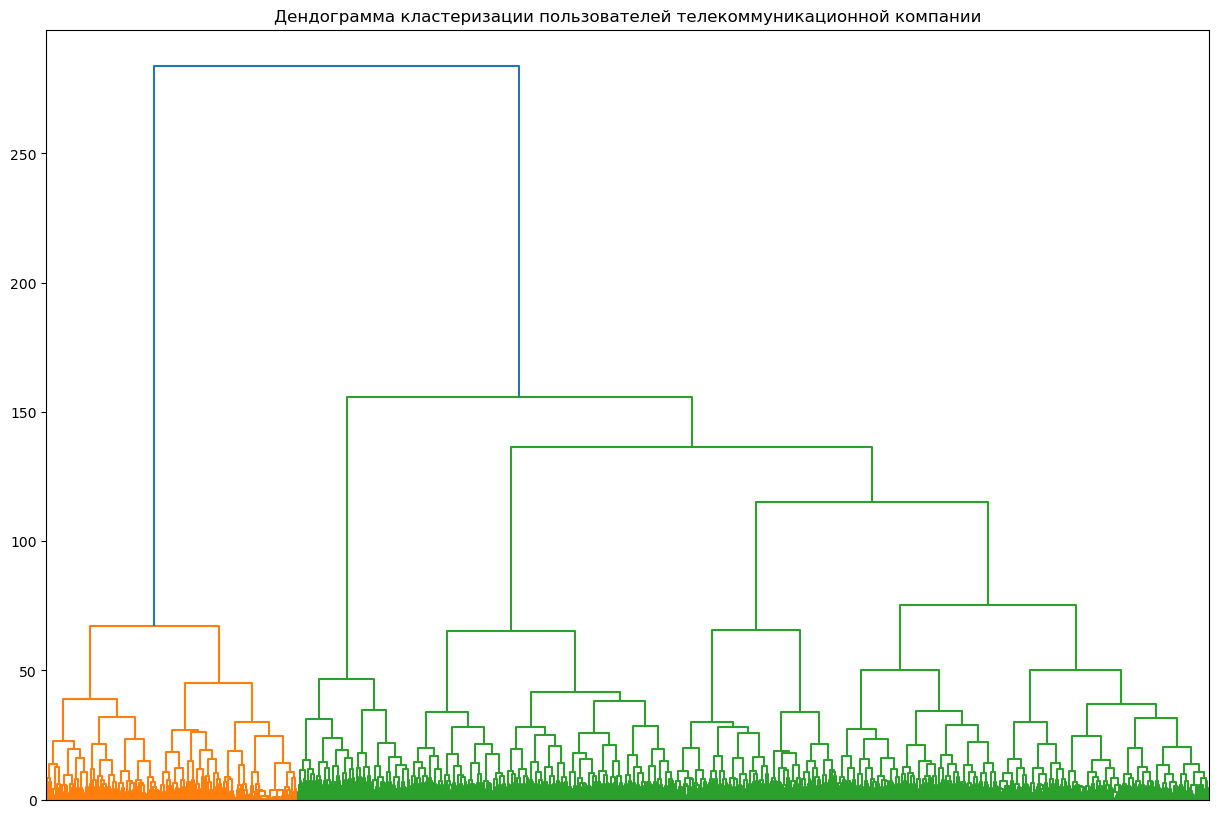

In [271]:
# уберем лишние колонки
X = df.drop(['customer_id', 'churn'], axis=1)

# стандартизируем данные
scaler = StandardScaler()
X = scaler.fit_transform(X)

# получаем матрицу расстояний
linked = linkage(X, method='ward')

# визуализируем дендограмму
plt.figure(figsize=(15,10))
dendrogram(linked, no_labels=True)

plt.title('Дендограмма кластеризации пользователей телекоммуникационной компании')
plt.show()

Дендрограмма показывает оптимальное число кластеров 5. Для последующей кластеризации методом k-means используем это значение.

In [275]:
# задаем модель k-means с числом кластеров 5
km = KMeans(n_clusters=5, random_state=0)

# прогнозируем кластеры для наблюдений
labels = km.fit_predict(X)

# добавляем метки кластера в датафрейм
df['cluster_km'] = labels

In [308]:
columns = [i for i in df.columns if df[i].nunique() <= 2]

# посмотрим на средние значения по кластерам
(
    df.groupby('cluster_km')
        .mean()['churn']
        .sort_values(ascending=False)
)

cluster_km
4    0.499392
2    0.424361
3    0.249267
1    0.114956
0    0.074050
Name: churn, dtype: float64

В результате кластеризации мы получили 5 кластеров пользователей:
- кластеры с метками 4 и 2 наиболее склонны к оттоку (50% и 42% соответственно)
- кластеры с метками 1 и 0 наименее склонны к оттоку (11% и 7% соответственно)
- кластер 3 со средним значением (25%)

## Диаграммы признаков по меткам кластеров

In [317]:
# сохраним данные в переменную df2
# для более понятных подписей оси X
df2 = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# сохраним метки кластеров в колонку 'cluster_km'
df2['cluster_km'] = labels

# сохраним колонки из датафрема df в df2
df2.columns = df.columns

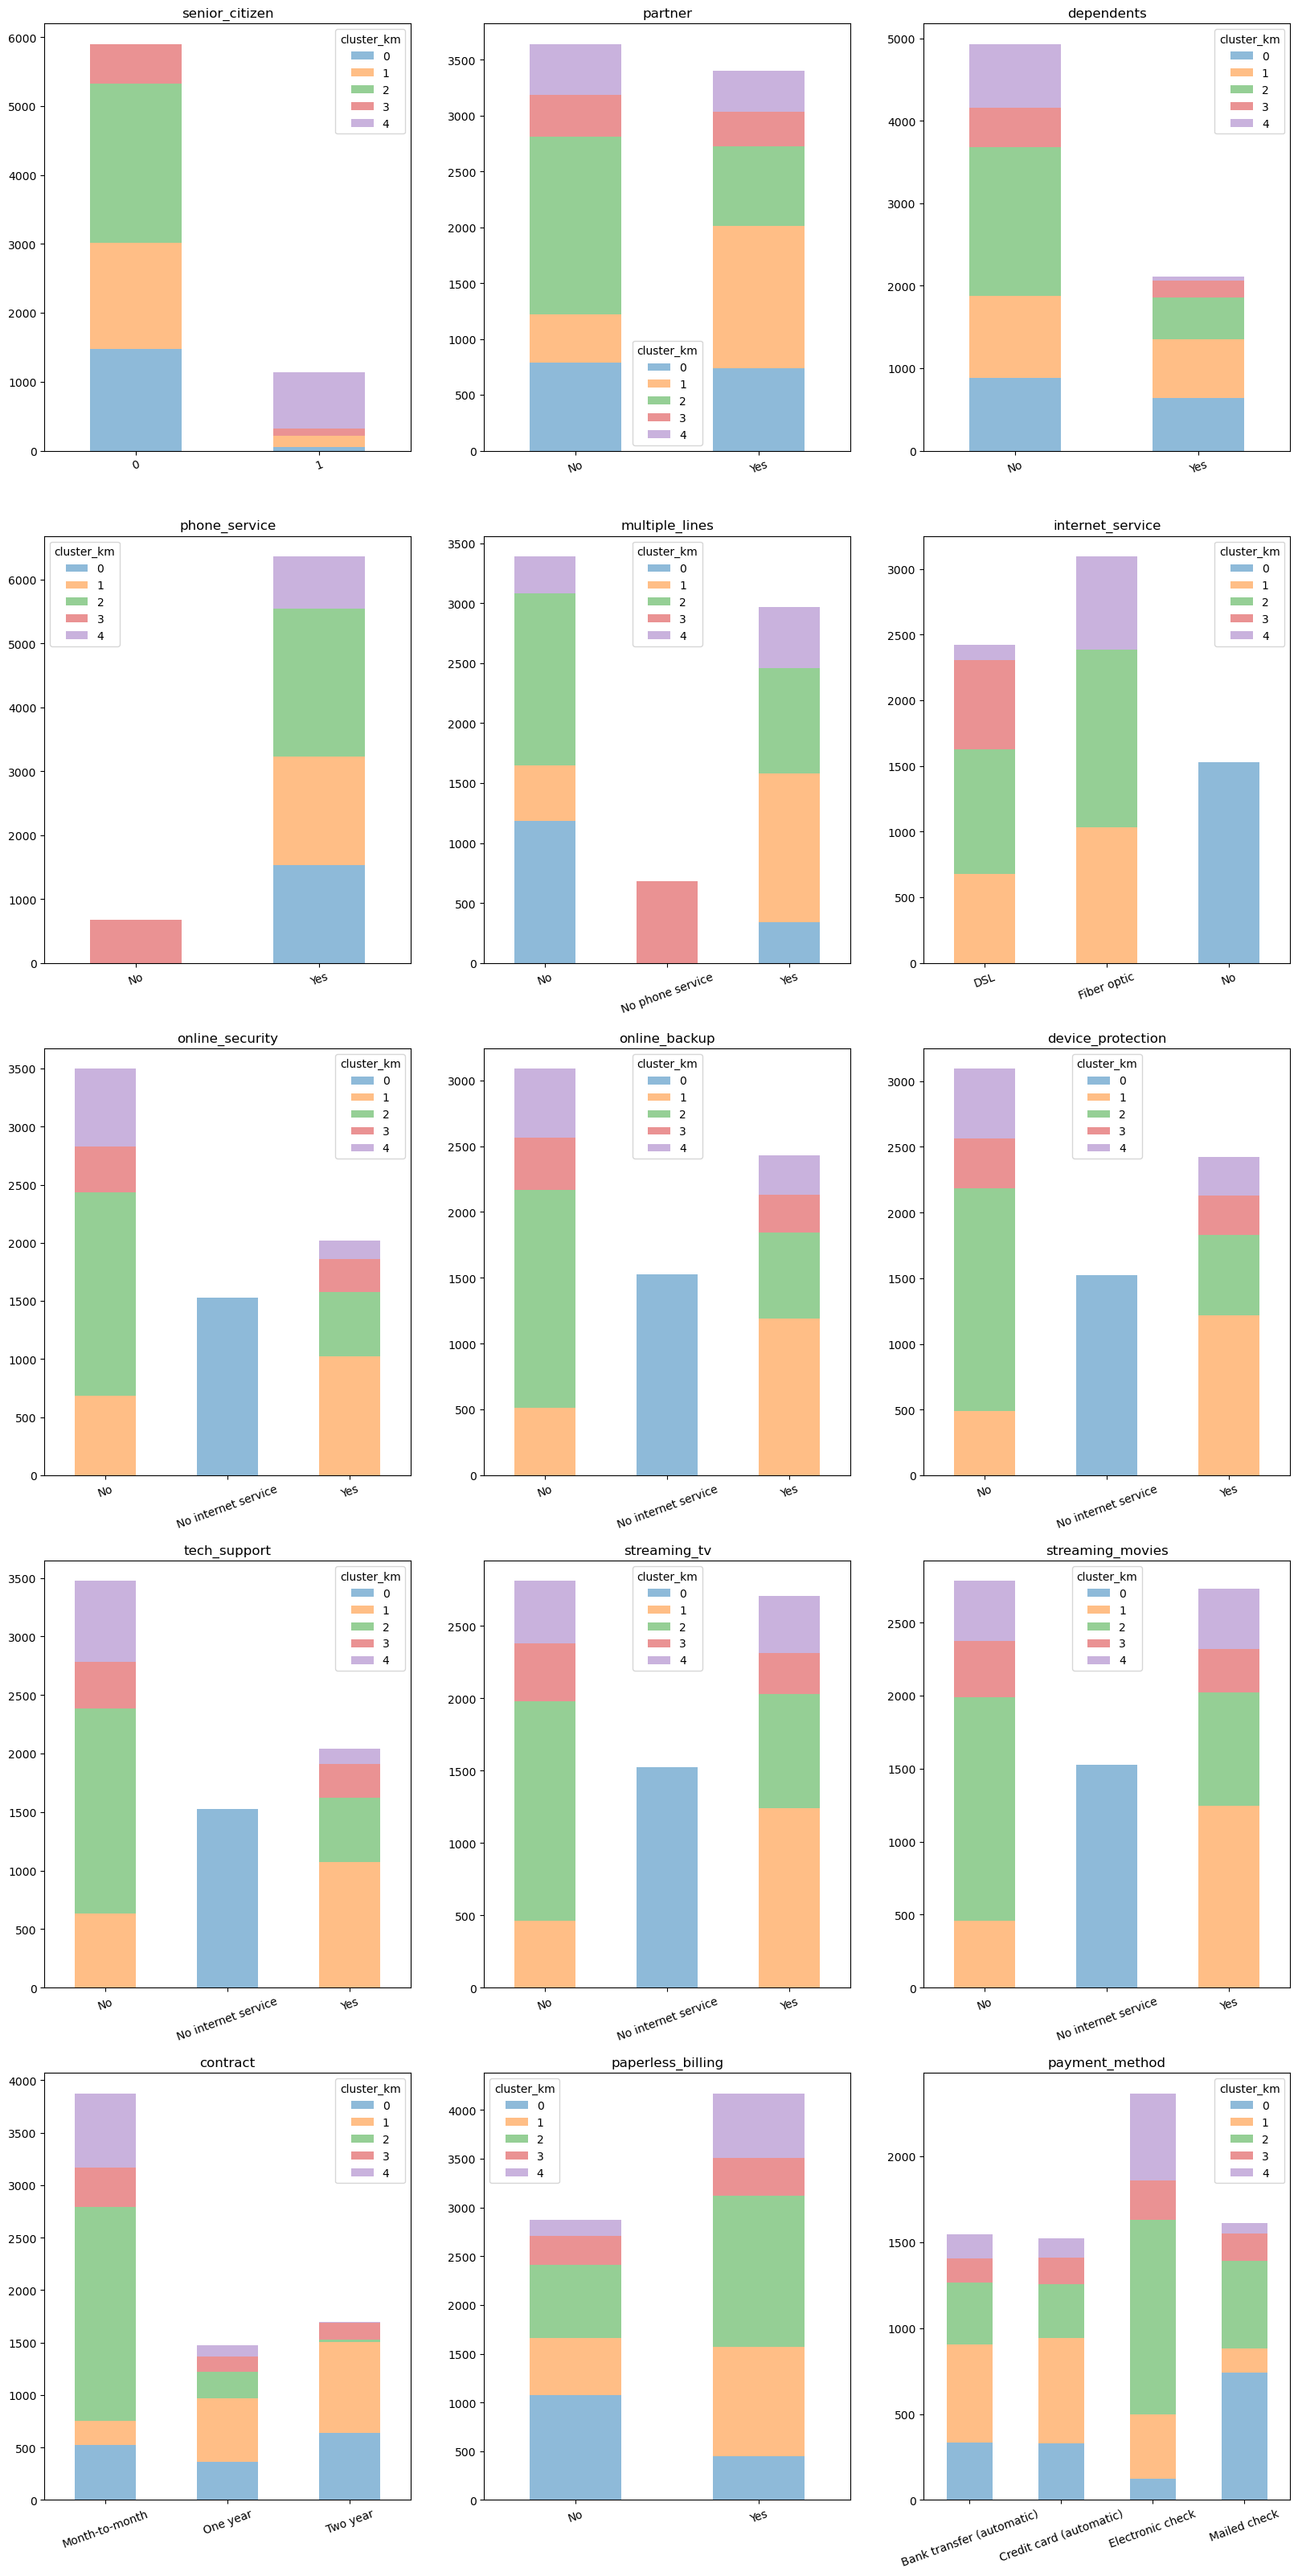

In [318]:
# список колонок для построение диаграмм
columns = [i for i in df2.columns if df2[i].nunique() <= 4 and i not in ['gender', 'churn']]

# создаем список графиков
fig, axs = plt.subplots(5, 3, figsize=(20, 40))

# изменяем размерность списка ax с 5х3 до 15х1
axs = axs.ravel()

# в цыкле создаем сводную таблицу
# и рисуем график этой таблицы
for i, col in enumerate(columns):
    report = df2.pivot_table(index=col, columns='cluster_km', values='gender', aggfunc='count')
    report.plot(ax=axs[i], kind='bar', stacked=True, alpha=0.5)
    axs[i].set_title(col)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('')
    axs[i].tick_params(axis='x', labelrotation=20)
    
plt.show()

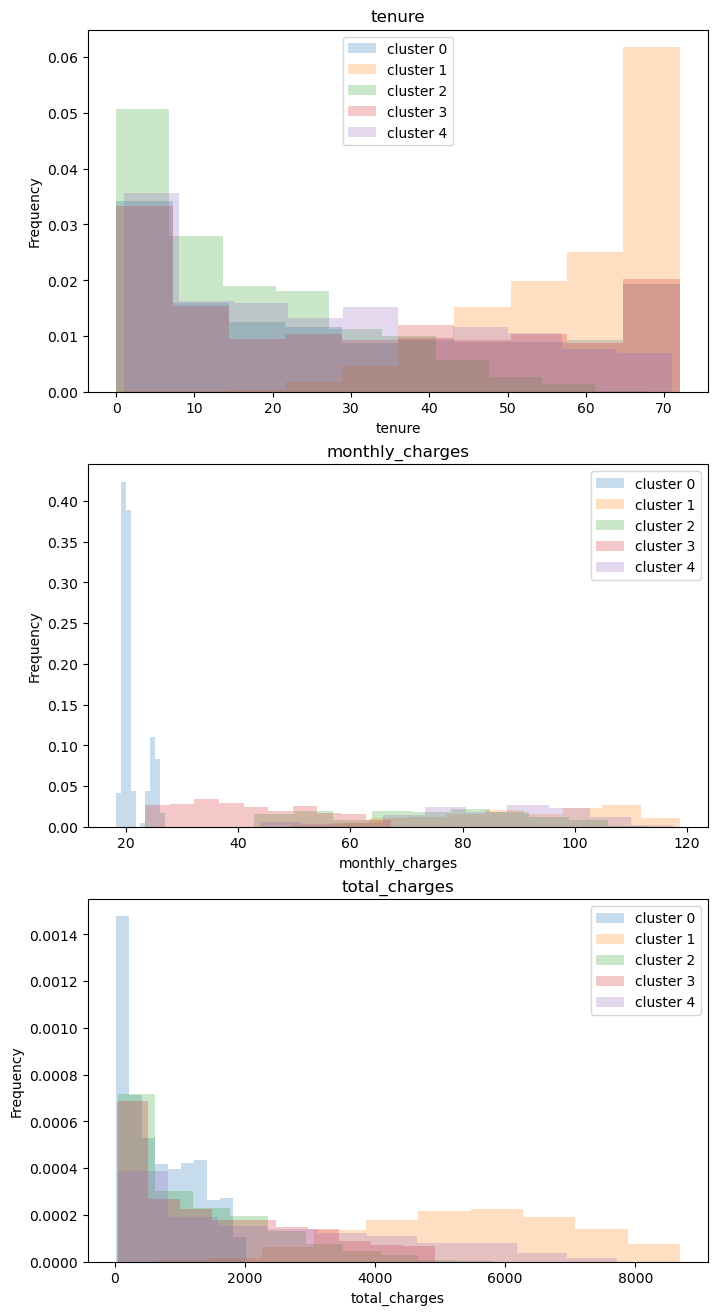

In [321]:
columns = ['tenure', 'monthly_charges', 'total_charges']

fig, axs = plt.subplots(3, 1, figsize=(8, 16))
axs = axs.ravel()

for i, col in enumerate(columns):
    (
        df[df['cluster_km'] == 0][col]
            .plot(
                ax=axs[i],
                kind='hist',
                density=True,
                alpha=0.25,
                label='cluster 0',
                legend=True
            )
    )
    (
        df[df['cluster_km'] == 1][col]
            .plot(
                ax=axs[i],
                kind='hist',
                density=True,
                alpha=0.25,
                label='cluster 1',
                legend=True
            )
    )
    (
        df[df['cluster_km'] == 2][col]
            .plot(
                ax=axs[i],
                kind='hist',
                density=True,
                alpha=0.25,
                label='cluster 2',
                legend=True
            )
    )
    (
        df[df['cluster_km'] == 3][col]
            .plot(
                ax=axs[i],
                kind='hist',
                density=True,
                alpha=0.25,
                label='cluster 3',
                legend=True
            )
    )
    (
        df[df['cluster_km'] == 4][col]
            .plot(
                ax=axs[i],
                kind='hist',
                density=True,
                alpha=0.25,
                label='cluster 4',
                legend=True
            )
    )
    axs[i].set_title(col)
    axs[i].set_xlabel(col)
plt.show()

**На визуализации распределения признаков для кластеров можно отметить**

Склонный к оттоку кластер 4: 
- старше 65 лет
- подключен интернет по оптоволокну
- не пользуется дополнительными услугами
- контракт без даты окончания
- оплачивает услуги онлайн
- пользуется услугами компании меньше 10 месяцев

Склонный к оттоку  кластер 2:
- младше 65 лет
- не женат/замужем
- проживает без родственников
- не использует несколько телефоных линий от компании
- не пользуется дополнительными услугами
- контракт без даты окончания
- оплачивает услуги онлайн
- пользуется услугами компании меньше 10 месяцев

Не склонный к оттоку кластер 0:
- младше 65 лет
- подключена одна телефонная линия
- не подключен интернет
- не пользуется дополнительными услугами
- предпочитает оплачивать услуги почтовыми чеками
- меньше всех платит в месяц

Не склонный к оттоку кластер 1:
- младше 65 лет
- женат/замужем
- пользуются несколькими телефонными линиями
- подключен интернет по оптоволокну или DSL
- пользуются дополнительными услугами
- имеет контракт на 1-2 года
- пользуется услугами компании 70 месяцев и более
- ежемесячно платит больше 70 уе
- имеют самые крупные общие расходы

#### Выводы

С помощью kmeans мы выполнили кластеризацию пользователей телекоммуникационной компании. Полученные 5 кластеров отличаются средним значением оттока.

В таблице ниже выделены особенности каждого кластера.

|Кластер|% оттока|Ключевые особенности|
|:--|:--|:--|
|0|7.4|меньше всех платит в месяц, предпочитает оплачивать услуги почтовыми чеками|
|1|11.4|пользуется дополнительными услугами, имеет контракт на 1-2 года, пользуется услугами компании 70 месяцев и более, имеет самые крупные общие расходы|
|**2**|**42.4**|не пользуется дополнительными услугами, контракт без даты окончания, пользуется услугами компании меньше 10 месяцев|
|3|24.9|не пользуется услугами домашней телефонной связи от компании, подключен интернет по DSL|
|**4**|**49.9**|не пользуется дополнительными услугами, контракт без даты окончания, пользуется услугами компании меньше 10 месяцев|

# Выводы

Нам доступны данные о пользователях вымешленной телекоммуникационной компании Telco. На этапе предобработки данных мы исправили стиль названия колонок, заменили пропуски, заменили значения бинарных колонок и убедились что дубликаты отсутствуют.

Анализ средних значений нам показал:
- большинство пользователей младше 65 лет
- почти все пользователи используют телефонную связь от компании Telco
- в среднем клиент пользуетя услугами компании 32 месяца
- 27% пользователей ушли в отток

Сравнив пользователей попавших в отток, с теми кто не попал в группу оттока, мы увидели основные отличия:
- чаще заключают контракт без даты окончания и оплачивают услуги онлайн
- меньше пользуются дополнительными услугами
- большинство тех, кто попал в группу оттока, пользуються услугами компании меньше 10 месяцев

Методом k-means мы выполнили кластеризацию и получили 5 кластеров, которые отличаются средними значениями оттока. Для каждого кластера сформаровали рекомендации по взаимодействия с клиентами и их удержанием.

**Кластер 0** (7.4% оттока). Самая лояльная аудитория, приносит наименьшую выручку компании. Подключена телефонная связь и не подключен интернет, из-за этото недоступны все дополнительные услуги. Для поддержания лояльности предлогать подключить интернет с дополнительными услугами со скидкой к уже имеющейся телефонной связи. Можно делать акцент на долгосрочных контрактах 1-2 года.

**Кластер 1** (11.4% оттока). Лояльная аудитория. Отличается от кластера 0 тем, что подключен интернет и дополнительные услуги. Больше всех пользуется дополнительными услугами, более активно заключает долгосрочные контракты, больше всех платит ежемесячно, дольше всех пользуется услугами компании. Как вариант, предлагать скидки на дополнительные услуги той части, которая не пользуется ими.

**Кластер 2** (42.4% оттока). Пользователи которые скорее всего уйдут в отток. Пользуются в основном телефонной связью и интернетом, заключен контракт без даты окончания. Предлагать заключить долгосрочный контракт на взаимовыгодных условиях. После, рекламировать дополнительные услуги со скидкой.

**Кластер 3** (24.9% оттока). Кластер выделяется только отсутствием телефонной связи и подключенным интернетом по DSL. Предлагать подключить телефонную связь и альтернативу DSL - оптоволокно, как возможность получить более быстрое интернет соединение.

**Кластер 4** (49.9% оттока). Пользователи которые скорее всего уйдут в отток. Пользуются в основном телефонной связью и интернетом, заключен контракт без даты окончания. Предлагать заключить долгосрочный контракт на взаимовыгодных условиях. После, рекламировать дополнительные услуги со скидкой.